In [1]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

from params import hole_r, hole_x, hole_y

In [2]:
grid_size = 101
#
results_dir = Path("comparison_results")
results_dir.mkdir(exist_ok=True)

In [3]:
coordinates = np.linspace(-1.0, 1.0, grid_size, dtype=np.float64)
x_grid, y_grid = np.meshgrid(coordinates, coordinates, indexing="xy")
outer_mask = x_grid**2 + y_grid**2 < 1.0
hole_mask = (x_grid - hole_x) ** 2 + (y_grid - hole_y) ** 2 < hole_r**2
mask = outer_mask & ~hole_mask
xy = np.column_stack((x_grid[mask], y_grid[mask]))

Text(0, 0.5, 'y')

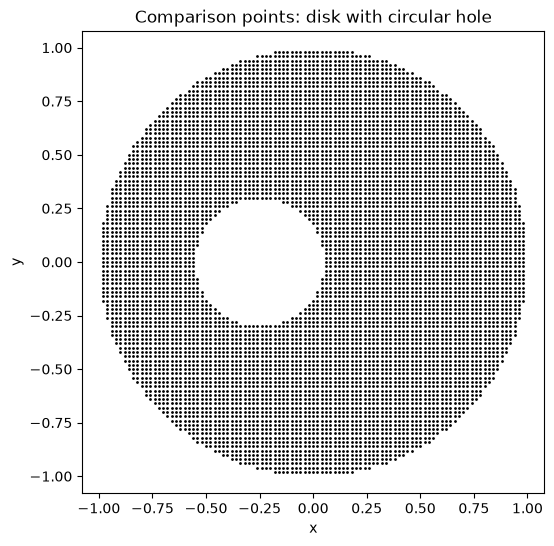

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(xy[:, 0], xy[:, 1], s=1.0, color="black")
plt.gca().set_aspect("equal")
plt.title("Comparison points: disk with circular hole")
plt.xlabel("x")
plt.ylabel("y")

In [5]:
np.savetxt(results_dir / "comparison_points.txt", xy, fmt="%.16f", delimiter="\t")